## Forecast Feasibility Audit: Interpretation Note

This notebook evaluates whether the generated forecasts are operationally plausible before they are used in downstream inventory optimization.

The feasibility checks include visual continuation, seasonal decomposition, year-over-year growth benchmarking, and exogenous cause-and-effect review. These checks are not intended to replace validation metrics such as MAPE, MAE, or RMSE. They are also not intended to force nonlinear machine learning models to behave like linear statistical time-series models.

This distinction is important because models such as XGBoost are nonlinear tree-based models. Their predictions do not need to decompose cleanly into trend, seasonality, and residual components in the same way as SARIMAX or other statistical models.

Therefore, the purpose of this audit is not to claim that a nonlinear model is invalid simply because it does not follow a smooth additive decomposition pattern. Instead, the audit is used to detect operational risk signals, such as:

* unrealistic discontinuities between historical demand and forecasted demand;
* implausible year-over-year growth or collapse;
* forecast behavior that conflicts strongly with known business drivers;
* forecast paths that could distort downstream inventory simulation.

The final decision should combine validation accuracy, deployment reliability, visual feasibility, and downstream inventory-modeling requirements.

## Notebook Role in the Forecasting Pipeline

| Item | Description |
|---|---|
| Notebook role | Operational forecast feasibility audit |
| Main question | Are the final forecasts plausible enough to be used in inventory optimization? |
| Main output | Visual continuation, decomposition, YoY, and exogenous-driver audit plots |
| Important caution | Feasibility checks are operational diagnostics, not strict linear interpretability tests |

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import os

# Define Paths
MAIN = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System'
DATA = os.path.join(MAIN, 'data')
RESULTS = os.path.join(MAIN, 'results')

# Load Training Data (Actuals)
train_df = pd.read_csv(os.path.join(DATA, 'final_train_df.csv'), parse_dates=['date'])

# Load Test Forecasts (Predictions)
test_pred_df = pd.read_csv(os.path.join(RESULTS, 'test_predictions_daily_edit_3.csv'), parse_dates=['date'])

# Set plot style
sns.set_theme(style="whitegrid")


In [43]:
def create_combined_timeline(train_df, test_pred_df, target_family):
    """
    Combines the historical actuals and future predictions into a single timeline.
    """
    # 1. Filter Train Data
    train_family = train_df[train_df['family'] == target_family].copy()
    train_family = train_family.groupby('date')['sales'].sum().reset_index()
    train_family['type'] = 'Actual'

    # 2. Filter Test Forecast Data
    test_family = test_pred_df[test_pred_df['family'] == target_family].copy()
    test_family = test_family.groupby('date')['daily_forecast_sales'].sum().reset_index()
    test_family.rename(columns={'daily_forecast_sales': 'sales'}, inplace=True)
    test_family['type'] = 'Forecast'

    # 3. Combine into continuous timeline
    combined_df = pd.concat([train_family, test_family], ignore_index=True)
    combined_df = combined_df.sort_values('date').set_index('date')
    
    return combined_df, train_family, test_family


def plot_visual_continuation(combined_df, target_family):
    """
    Plots the immediate preceding months leading into the forecast to check momentum.
    """
    plot_start_date = '2017-05-01'
    recent_data = combined_df[combined_df.index >= plot_start_date]

    plt.figure(figsize=(16, 5))

    actuals = recent_data[recent_data['type'] == 'Actual']
    plt.plot(actuals.index, actuals['sales'], label='Actual Sales (Train)', color='blue', linewidth=2)

    forecasts = recent_data[recent_data['type'] == 'Forecast']
    plt.plot(forecasts.index, forecasts['sales'], label='Forecasted Sales (Test)', color='orange', linewidth=2, linestyle='--')

    plt.axvline(pd.to_datetime('2017-08-15'), color='red', linestyle=':', label='Forecast Boundary')

    plt.title(f"{target_family}: Recent Momentum & Forecast Continuation (May - Aug 2017)", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("Daily Sales")
    plt.legend()
    plt.tight_layout()
    safe_family = target_family.replace('/', '_').replace(' ', '_')
    save_path = os.path.join(RESULTS, f'visual_continuation_feasibility_{safe_family}_edit_3.png')
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()


def plot_combined_decomposition(combined_df, target_family):
    """
    Decomposes the combined timeline to ensure smooth transition of Trend and Seasonality.
    """
    decomp_data = combined_df[combined_df.index >= '2017-01-01']['sales']

    decomposition = seasonal_decompose(decomp_data, model='additive', period=7)

    fig, axes = plt.subplots(4, 1, figsize=(16, 8), sharex=True)

    decomposition.observed.plot(ax=axes[0], color='black')
    axes[0].set_ylabel('Observed')
    axes[0].axvline(pd.to_datetime('2017-08-15'), color='red', linestyle=':')

    decomposition.trend.plot(ax=axes[1], color='blue')
    axes[1].set_ylabel('Trend')
    axes[1].axvline(pd.to_datetime('2017-08-15'), color='red', linestyle=':')

    decomposition.seasonal.plot(ax=axes[2], color='green')
    axes[2].set_ylabel('Seasonal')
    axes[2].axvline(pd.to_datetime('2017-08-15'), color='red', linestyle=':')

    decomposition.resid.plot(ax=axes[3], color='purple', style='o', markersize=2)
    axes[3].set_ylabel('Residual')
    axes[3].axvline(pd.to_datetime('2017-08-15'), color='red', linestyle=':')

    plt.suptitle(f"Combined Decomposition for {target_family} (Train + Forecast)", fontsize=16)
    plt.tight_layout()
    safe_family = target_family.replace('/', '_').replace(' ', '_')
    save_path = os.path.join(RESULTS, f'combined_decomposition_feasibility_{safe_family}_edit_3.png')
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()


def plot_yoy_growth(train_family, test_family, target_family):
    """
    Calculates and plots the historical Year-over-Year trajectory for August.
    """
    yoy_data = []

    for year in [2014, 2015, 2016]:
        august_data = train_family[(train_family['date'] >= f'{year}-08-16') & (train_family['date'] <= f'{year}-08-31')]
        yoy_data.append({'Year': year, 'Avg_Daily_Sales': august_data['sales'].mean(), 'Type': 'Actual'})

    august_forecast = test_family[(test_family['date'] >= '2017-08-16') & (test_family['date'] <= '2017-08-31')]
    yoy_data.append({'Year': 2017, 'Avg_Daily_Sales': august_forecast['sales'].mean(), 'Type': 'Forecast'})

    yoy_df = pd.DataFrame(yoy_data)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=yoy_df, x='Year', y='Avg_Daily_Sales', hue='Type', dodge=False, palette={'Actual': 'blue', 'Forecast': 'orange'})

    plt.plot(range(len(yoy_df)), yoy_df['Avg_Daily_Sales'], color='red', marker='o', linestyle='-', linewidth=2)

    plt.title(f"{target_family}: Year-over-Year August (16-31) Trajectory", fontsize=16)
    plt.ylabel("Average Daily Sales")
    plt.ylim(0, yoy_df['Avg_Daily_Sales'].max() * 1.2)
    plt.tight_layout()
    safe_family = target_family.replace('/', '_').replace(' ', '_')
    save_path = os.path.join(RESULTS, f'yoy_growth_feasibility_{safe_family}_edit_3.png')
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()


def plot_exogenous_effect(test_family, target_family, data_path):
    """
    Overlays forecasted sales with exogenous promotion data to prove causal logic.
    """
    test_raw = pd.read_csv(os.path.join(data_path, 'final_test_df.csv'), parse_dates=['date'])
    test_promo = test_raw[test_raw['family'] == target_family].groupby('date')['onpromotion'].sum().reset_index()

    forecast_vs_promo = pd.merge(test_family, test_promo, on='date')

    fig, ax1 = plt.subplots(figsize=(16, 4))

    color = 'tab:orange'
    ax1.set_xlabel('Date (Aug 2017)')
    ax1.set_ylabel('Forecasted Sales', color=color)
    ax1.plot(forecast_vs_promo['date'], forecast_vs_promo['sales'], color=color, marker='o', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Items On Promotion', color=color)  
    ax2.bar(forecast_vs_promo['date'], forecast_vs_promo['onpromotion'], color=color, alpha=0.3)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"{target_family}: Forecasted Sales vs. Scheduled Promotions", fontsize=16)
    fig.tight_layout()  
    safe_family = target_family.replace('/', '_').replace(' ', '_')
    save_path = os.path.join(RESULTS, f'exogenous_effect_feasibility_{safe_family}_edit_3.png')
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()


In [44]:
forecasted_df = test_pred_df[~test_pred_df['daily_forecast_sales'].isna()]
forecasted_df.family.unique()

array(['BEVERAGES', 'BREAD/BAKERY', 'CLEANING', 'DAIRY', 'DELI',
       'GROCERY I', 'MEATS', 'PERSONAL CARE', 'POULTRY', 'PRODUCE'],
      dtype=object)

========================= EVALUATING FAMILY: BEVERAGES =========================


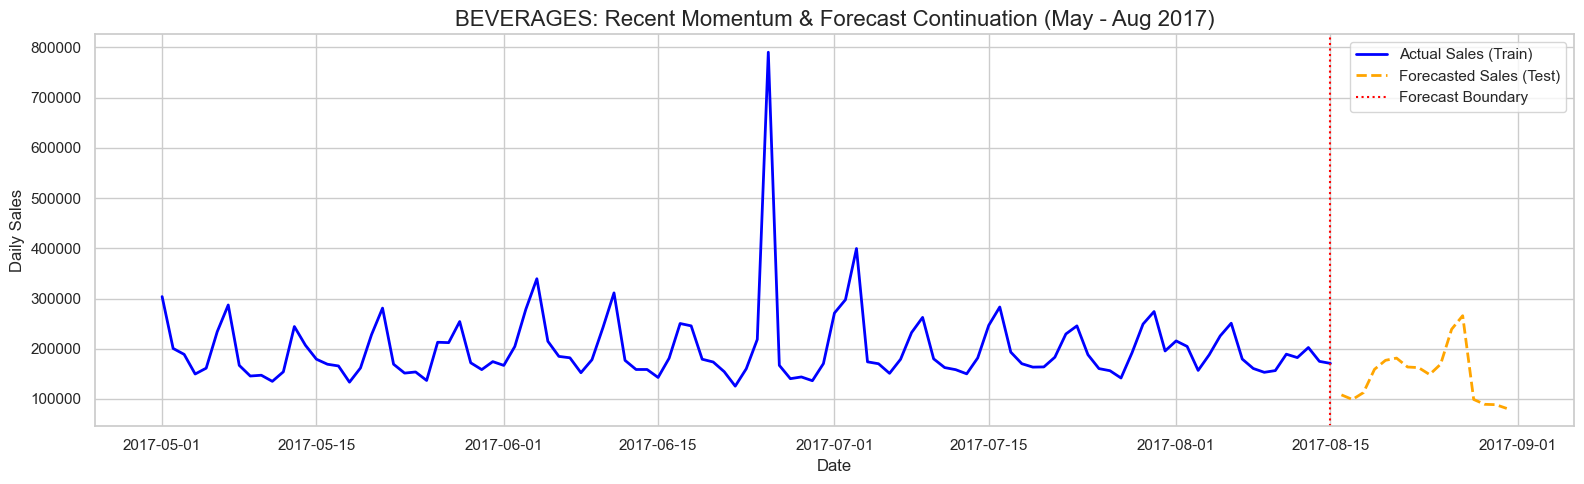

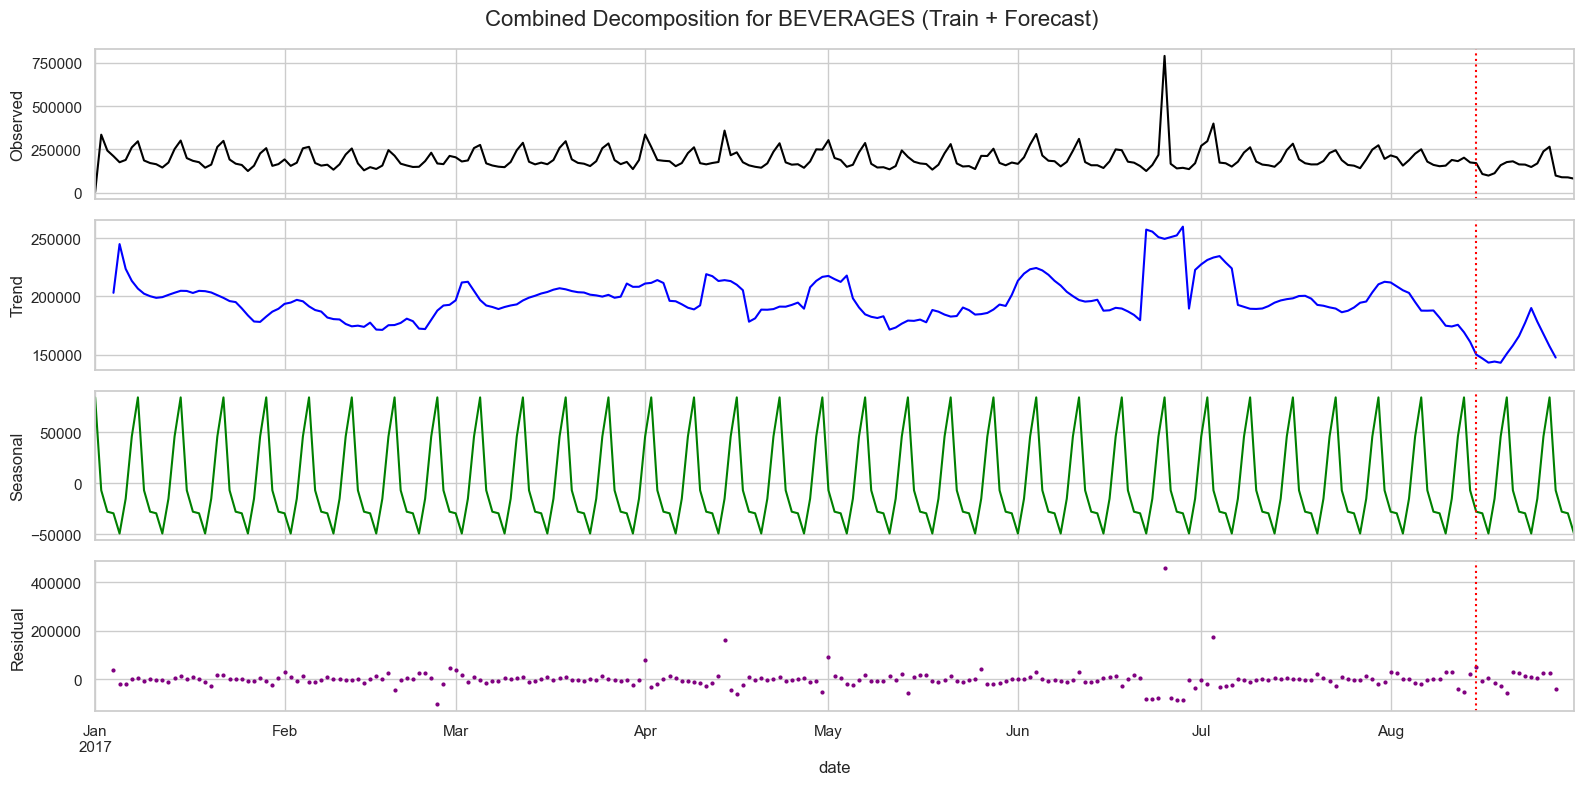

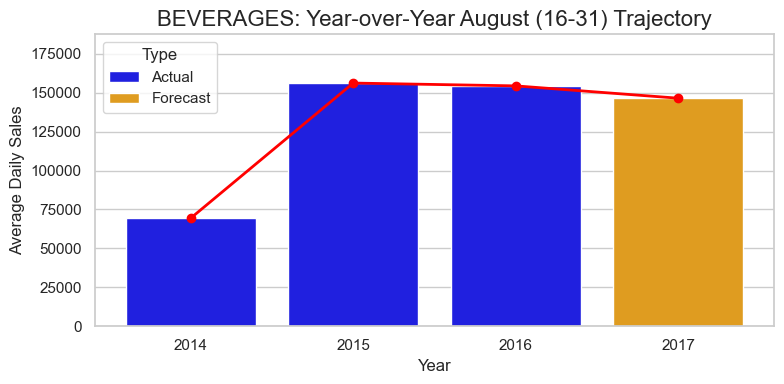

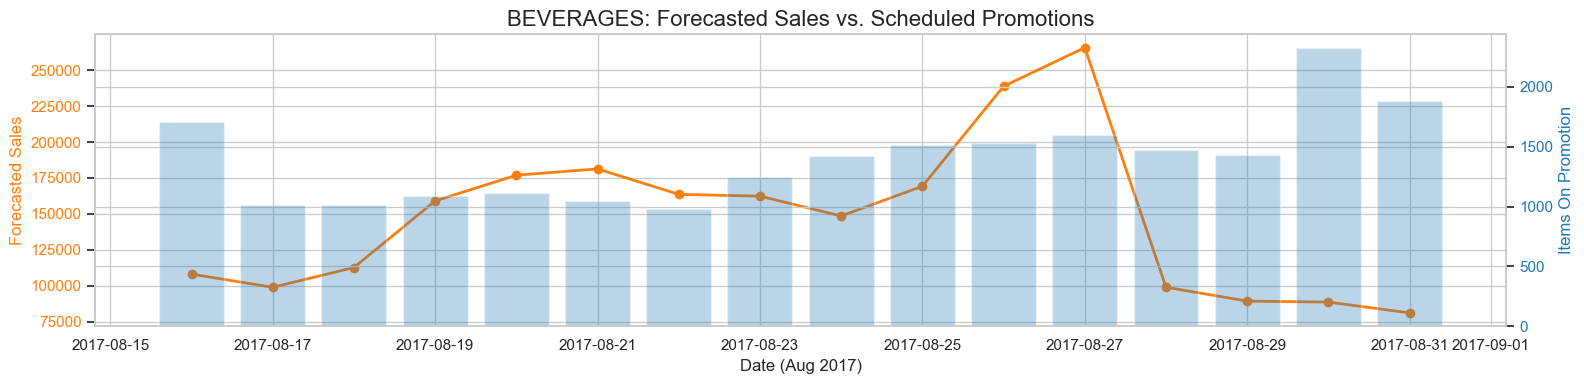


======================= EVALUATING FAMILY: BREAD/BAKERY ========================


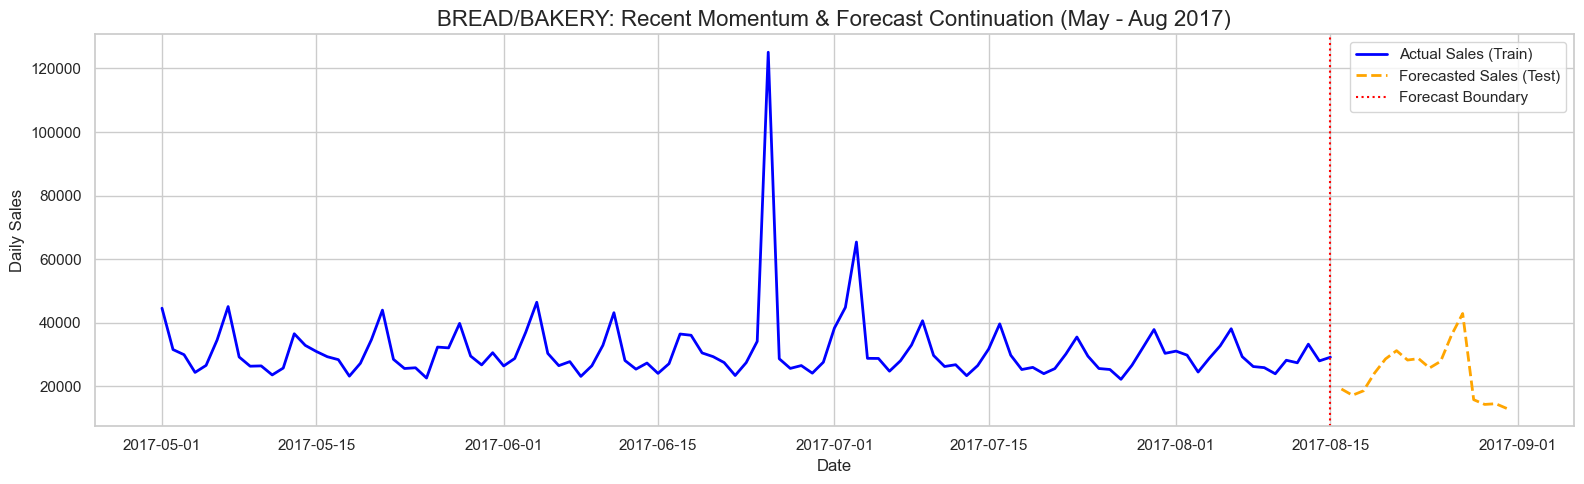

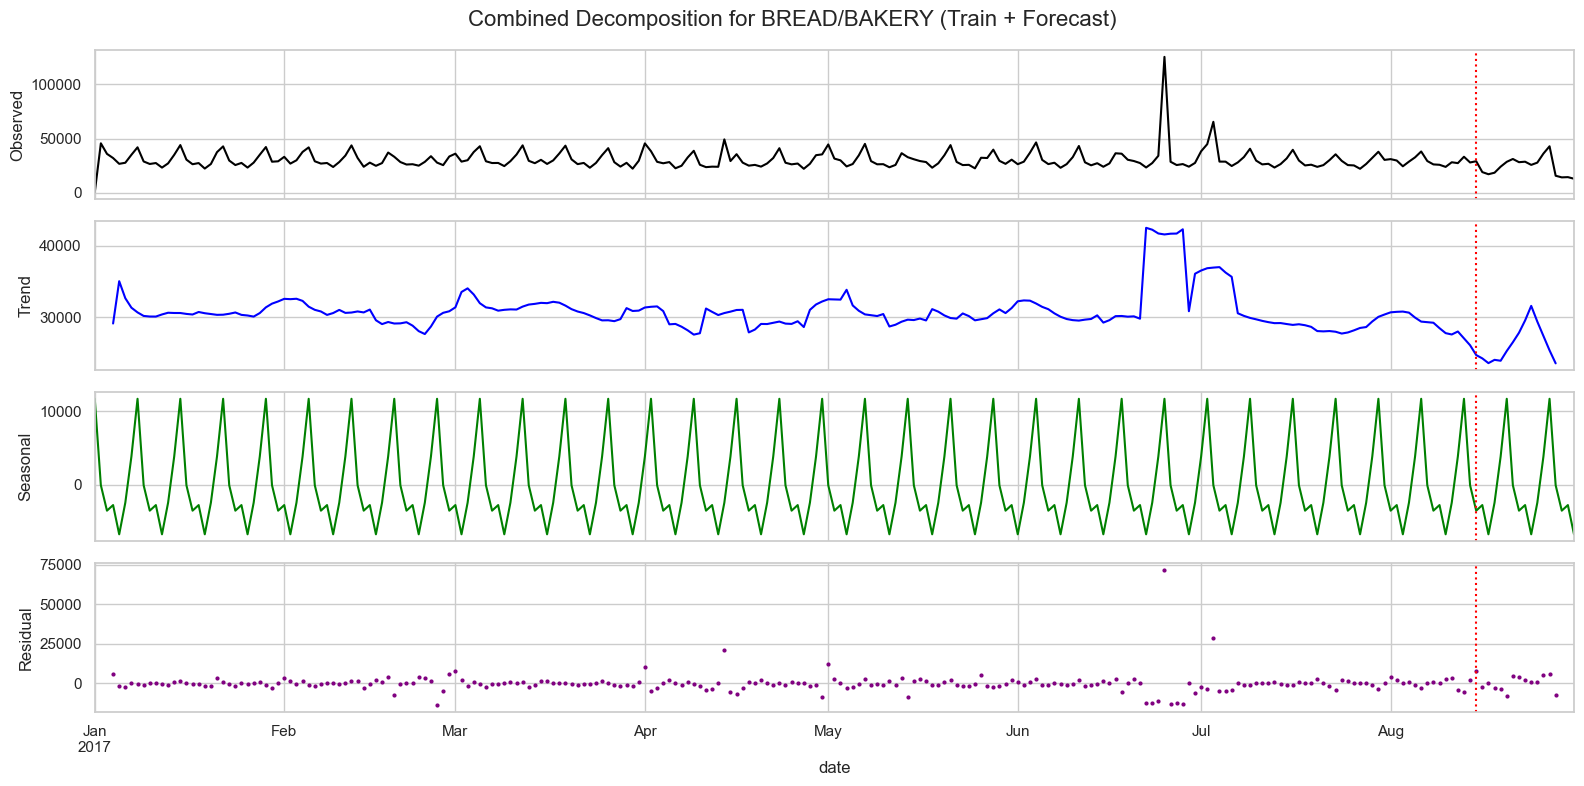

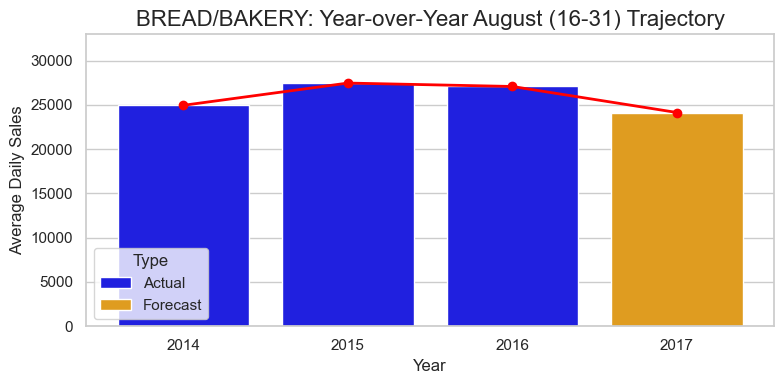

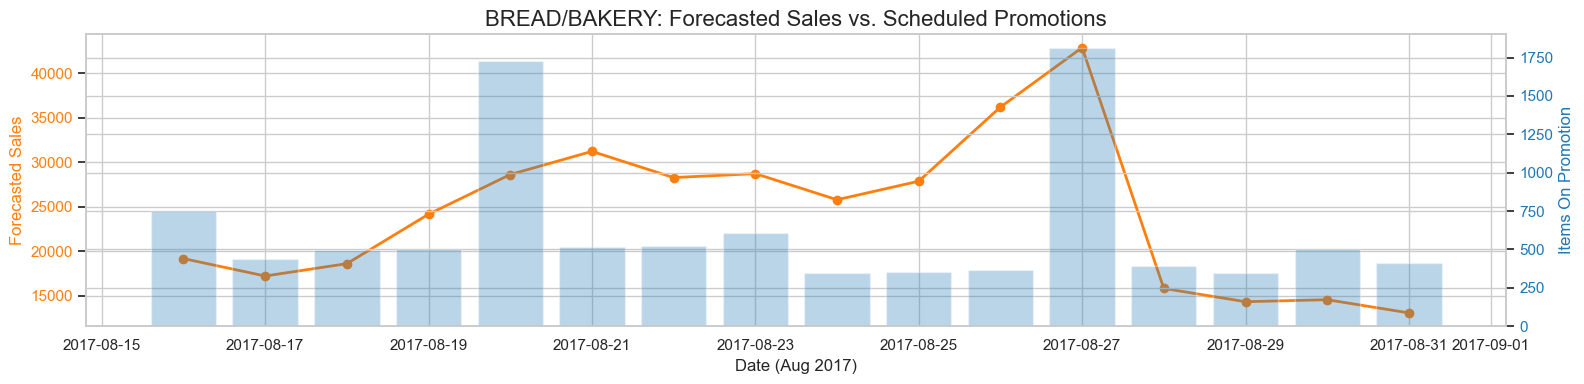


========================= EVALUATING FAMILY: CLEANING ==========================


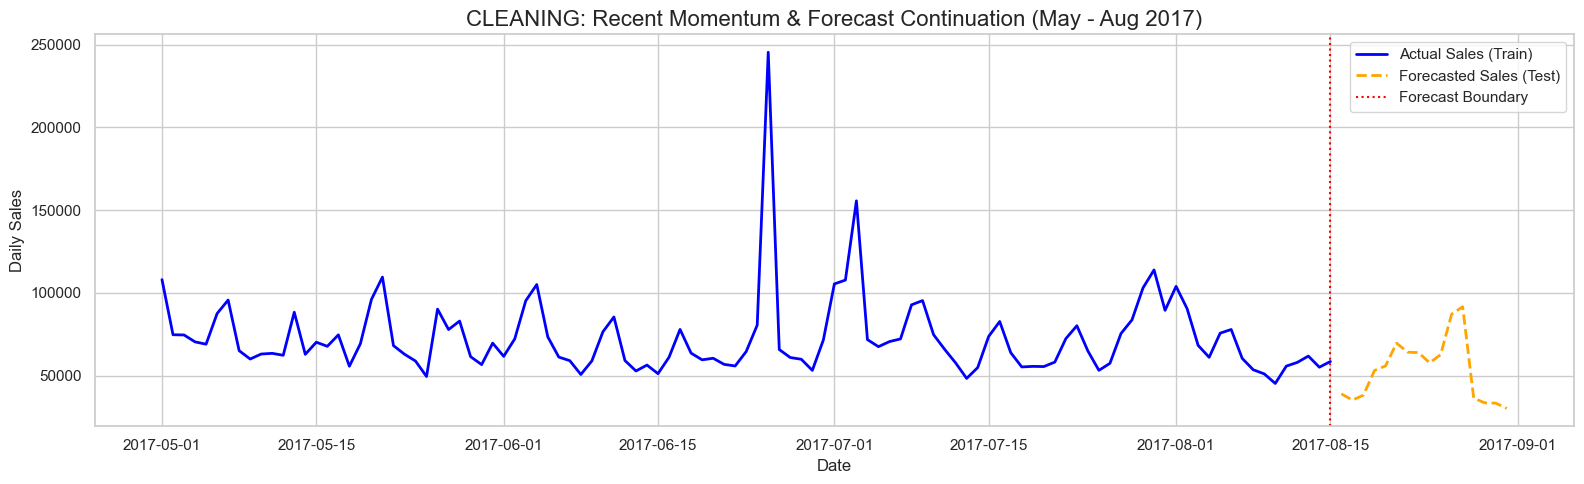

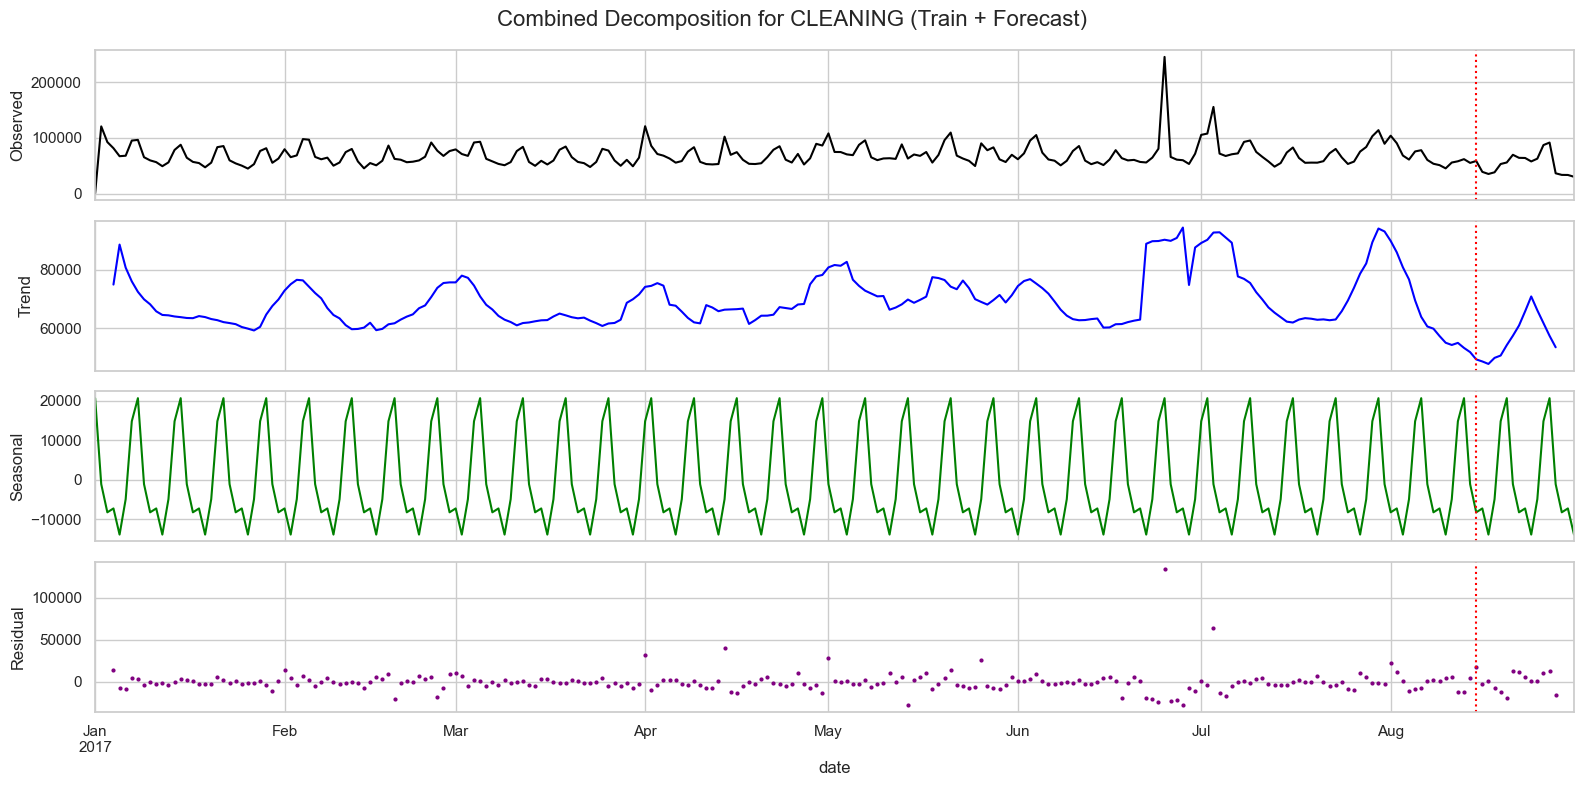

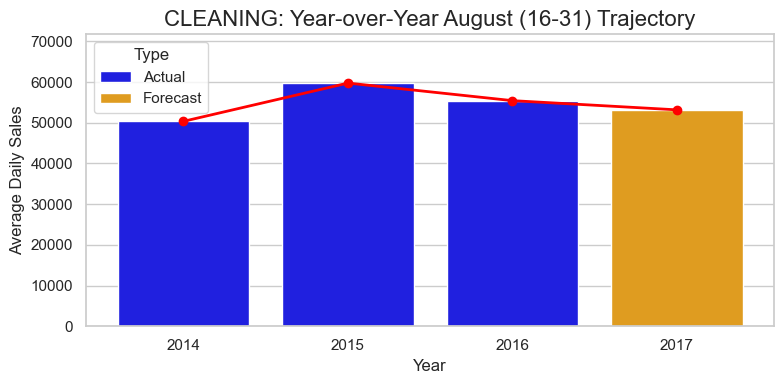

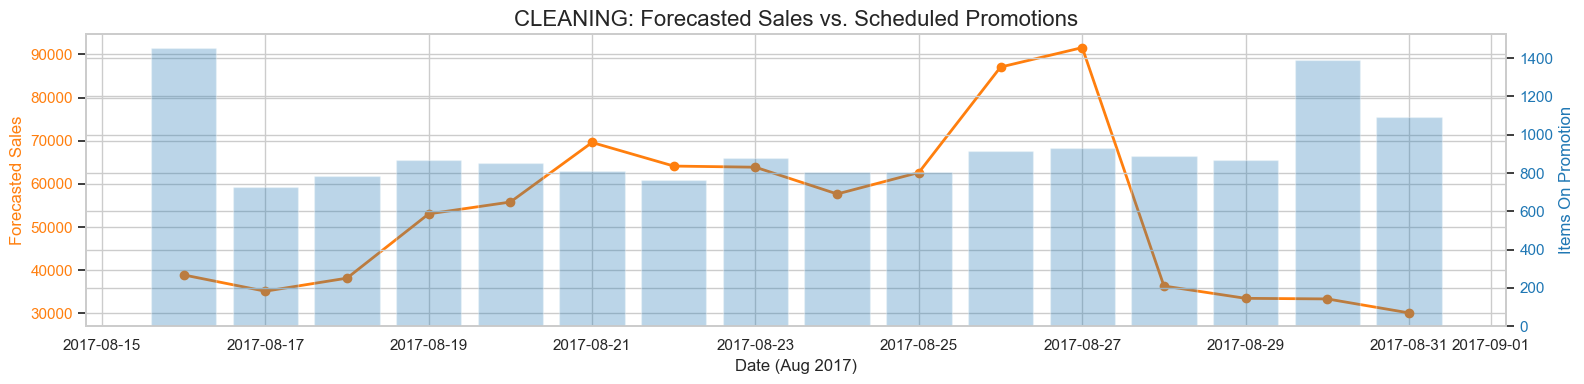


=========================== EVALUATING FAMILY: DAIRY ===========================


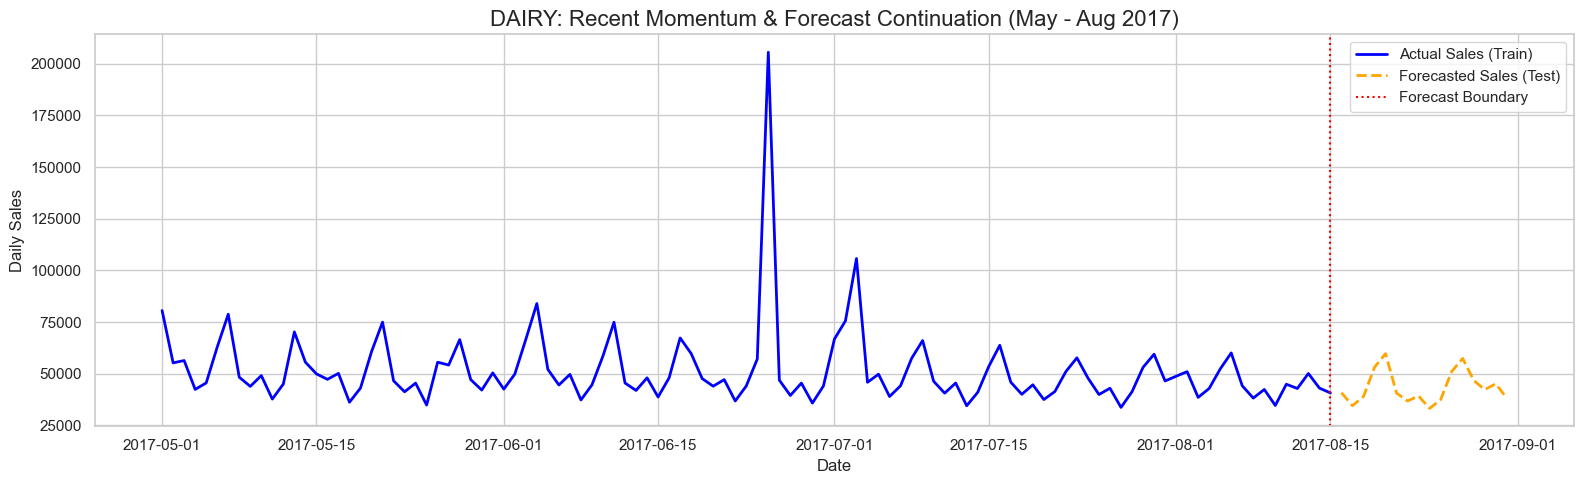

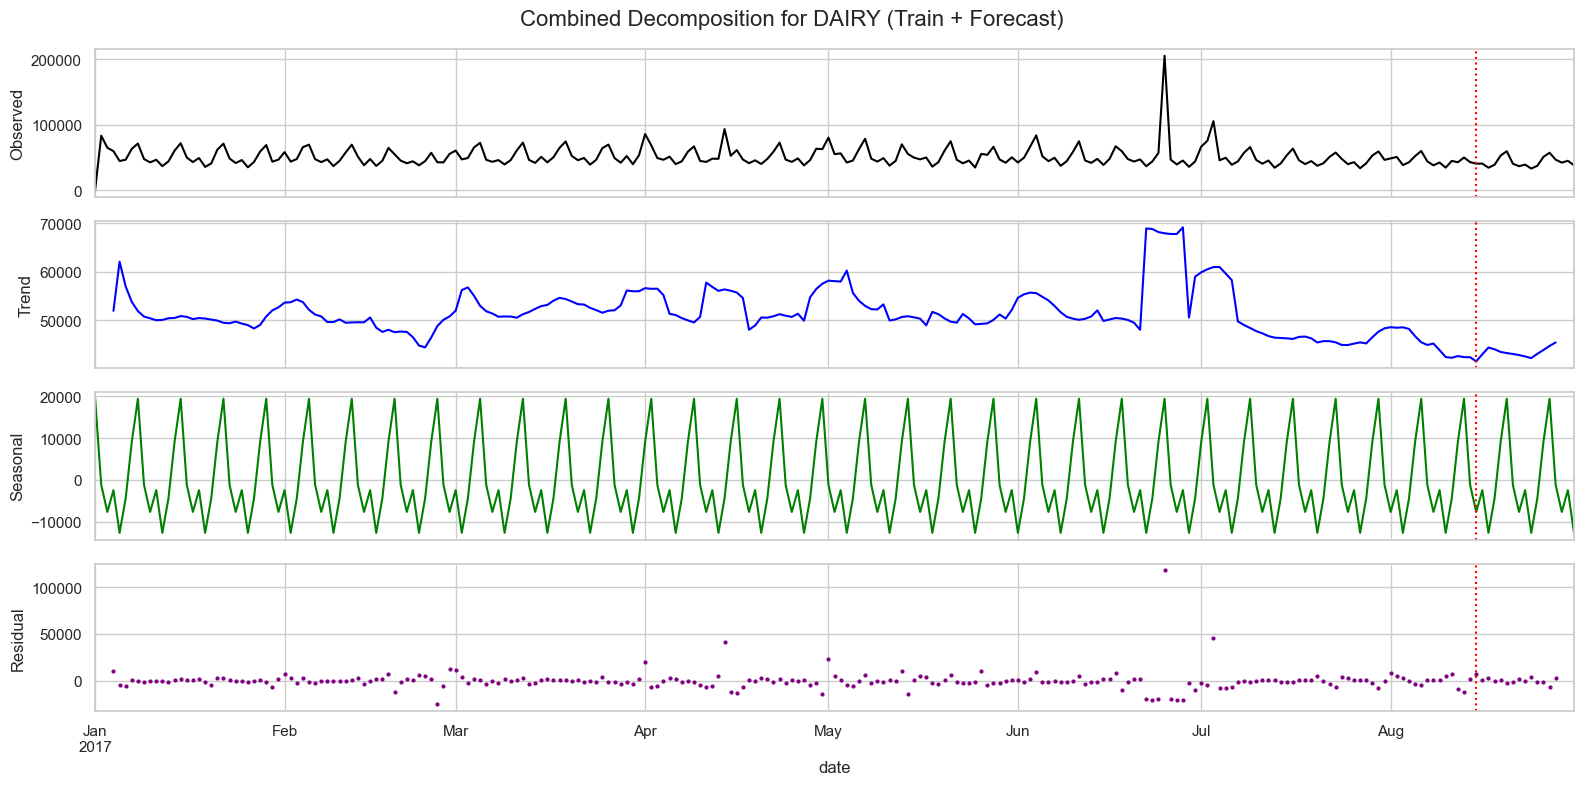

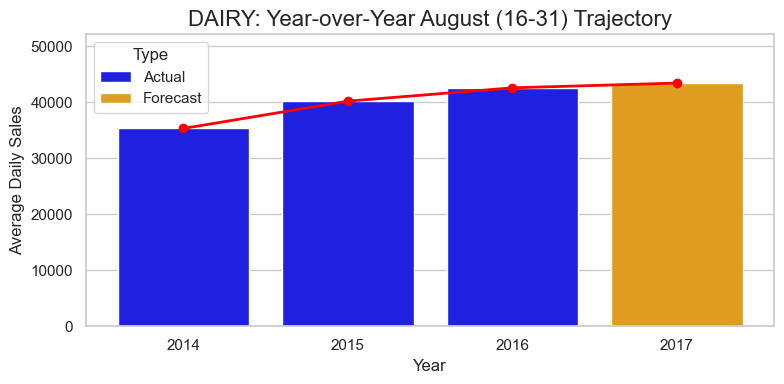

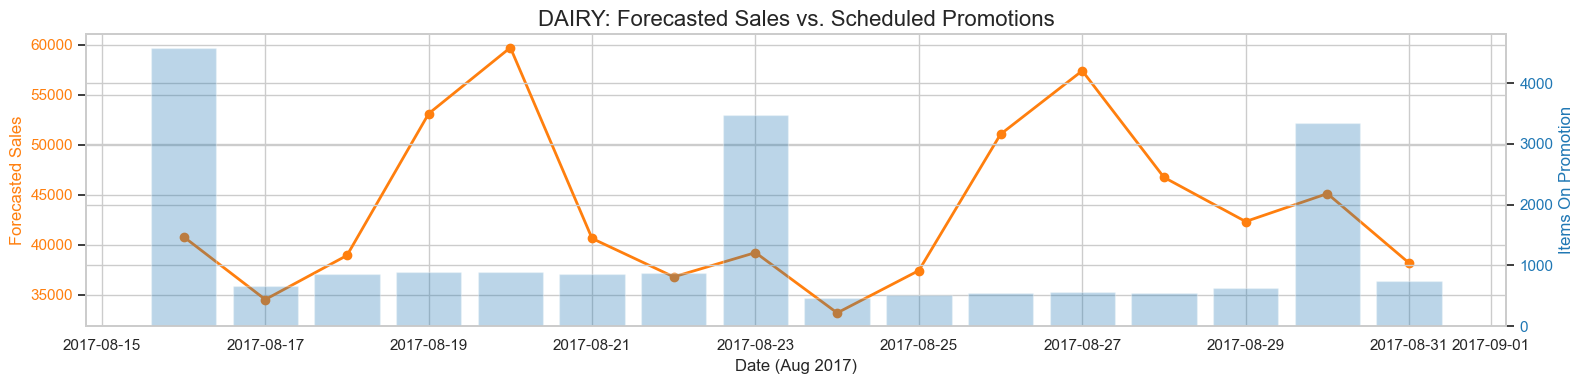


=========================== EVALUATING FAMILY: DELI ============================


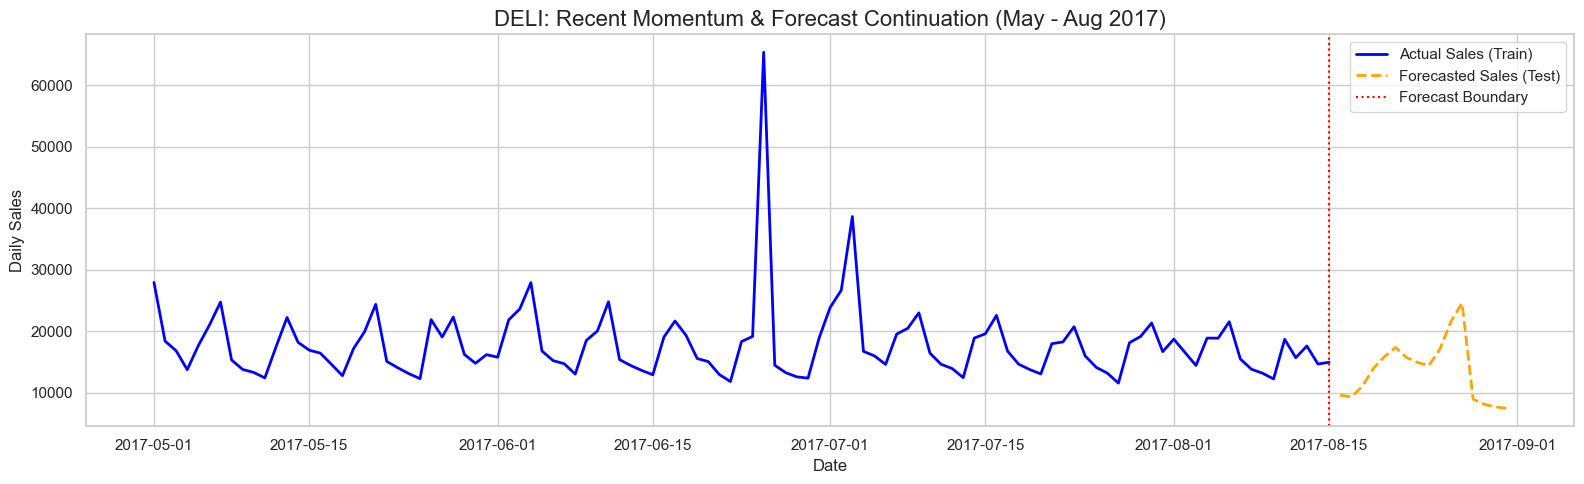

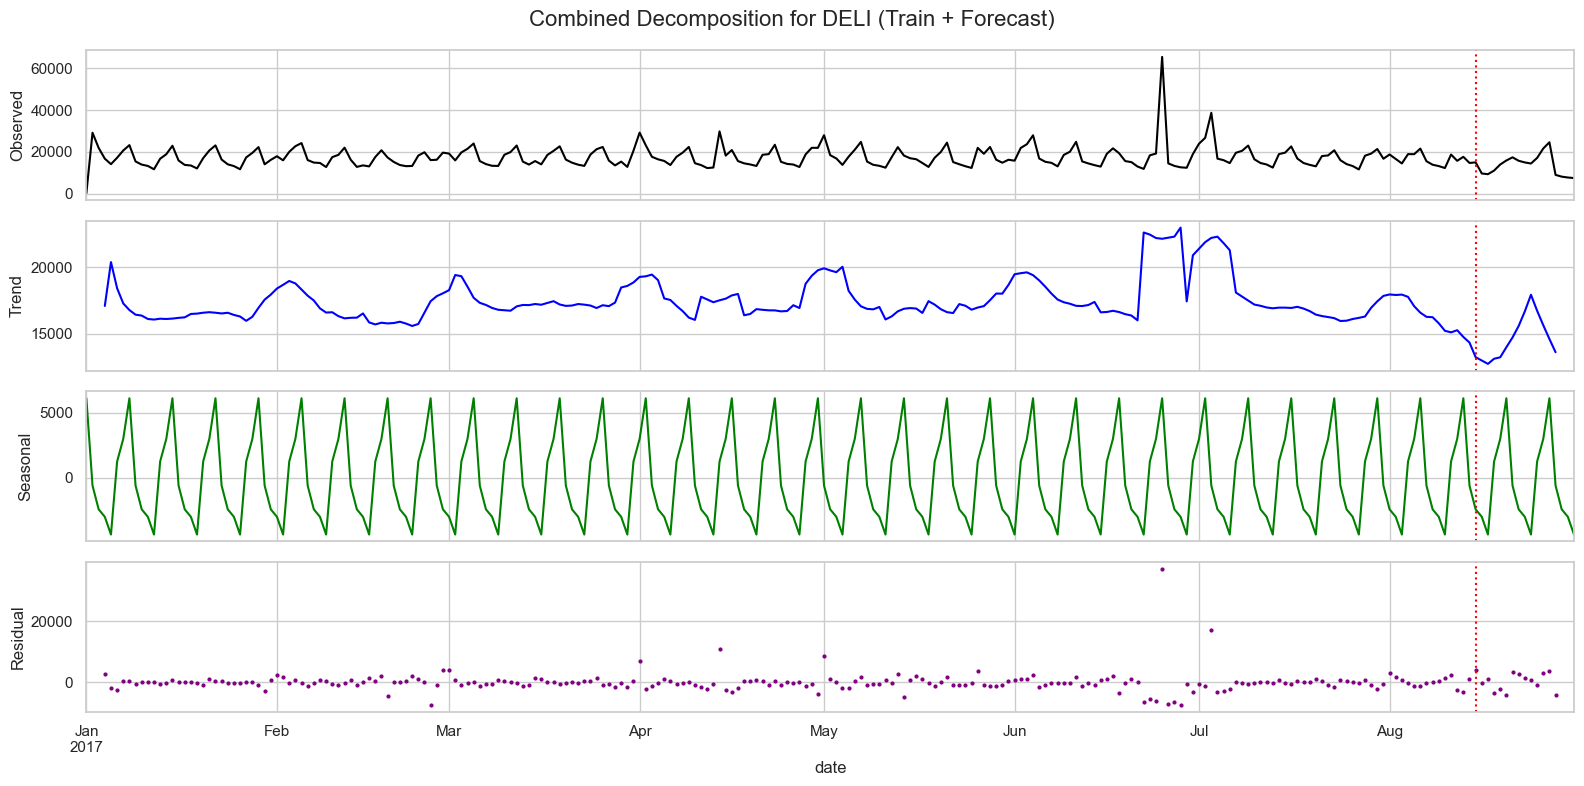

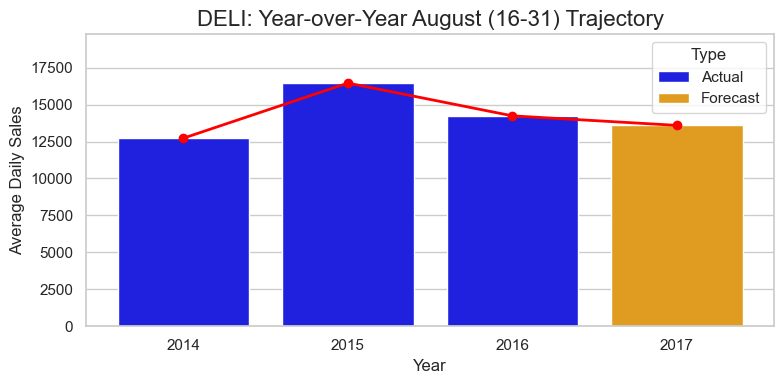

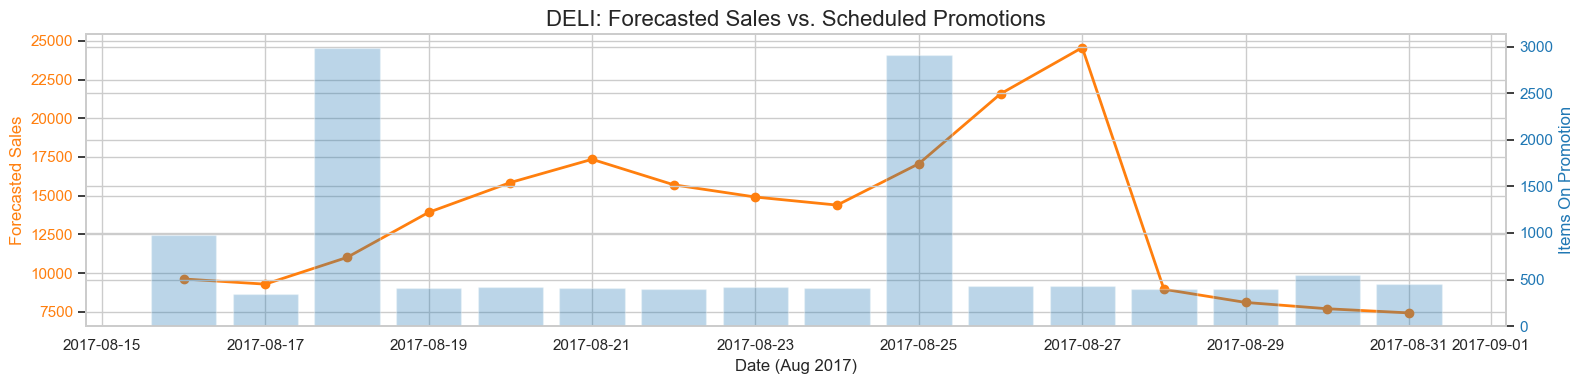


========================= EVALUATING FAMILY: GROCERY I =========================


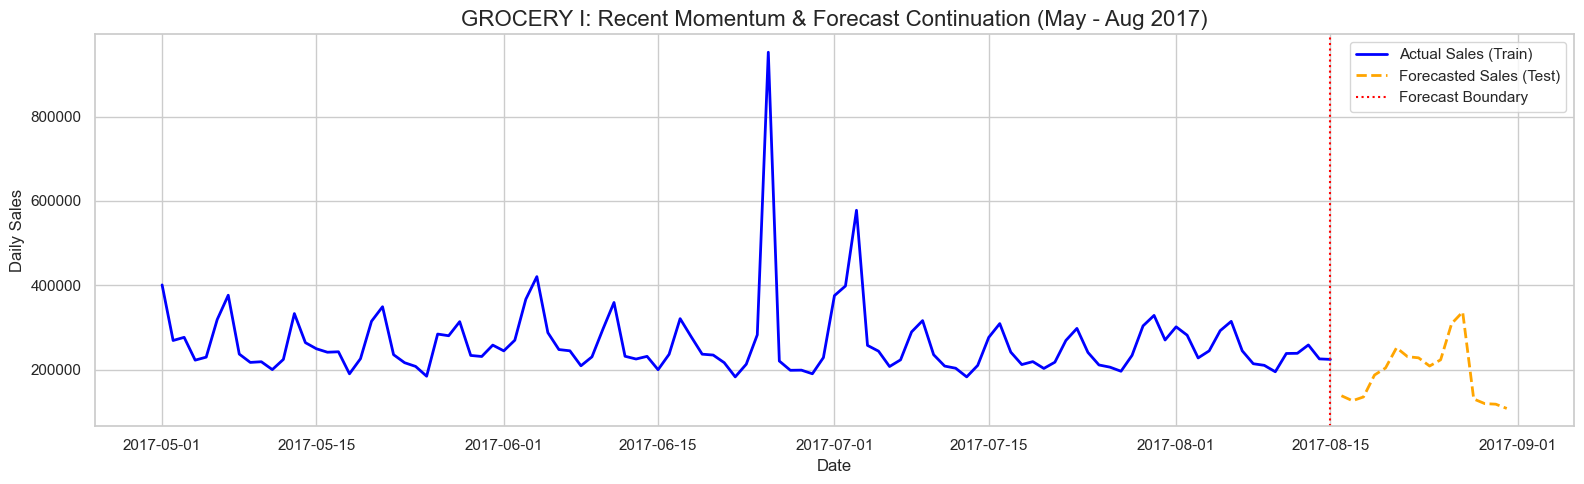

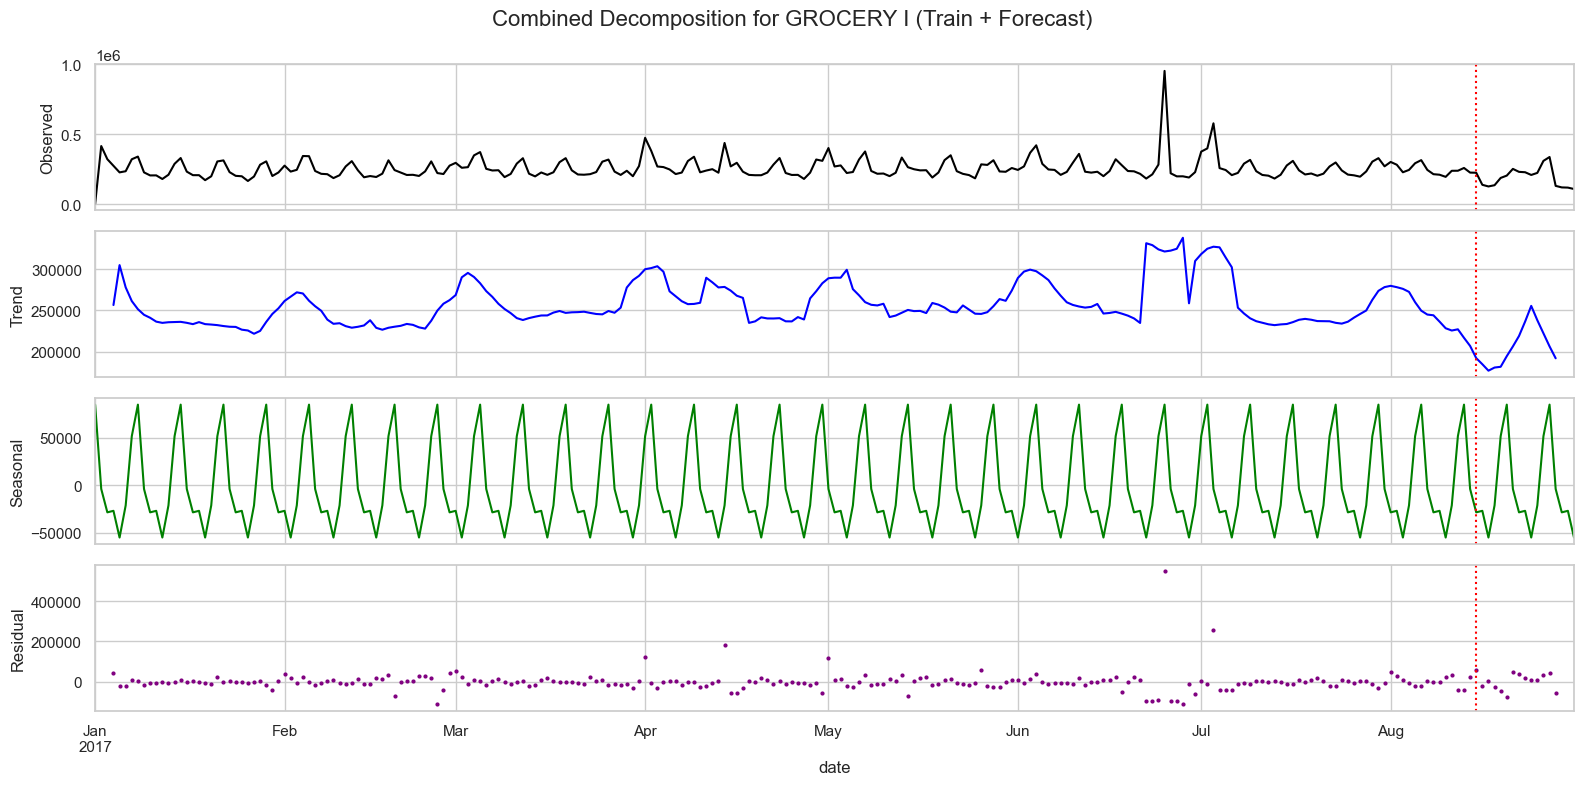

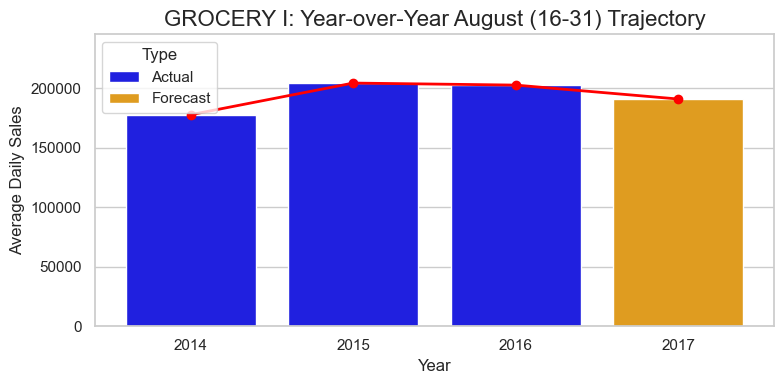

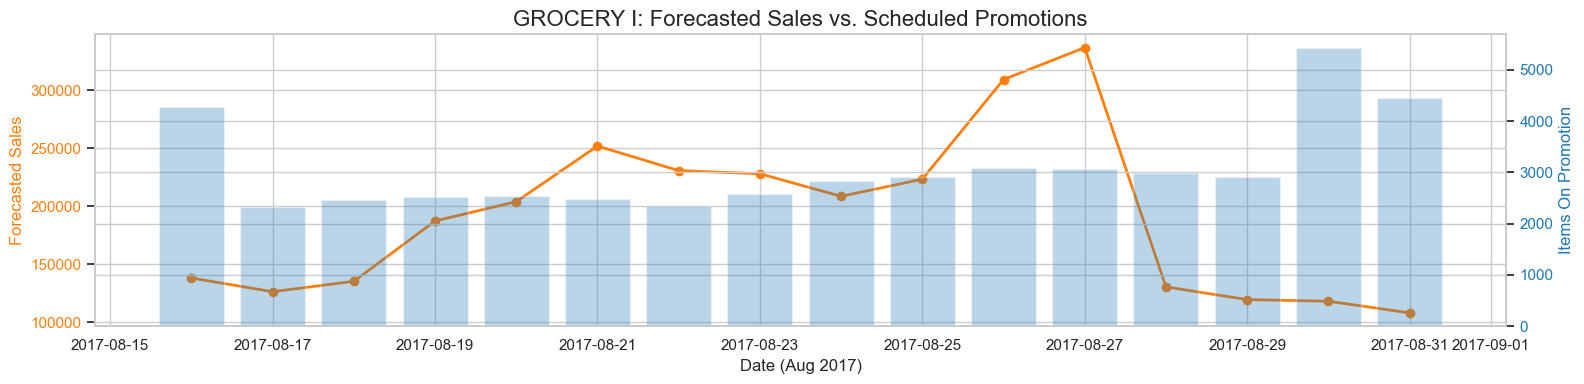


=========================== EVALUATING FAMILY: MEATS ===========================


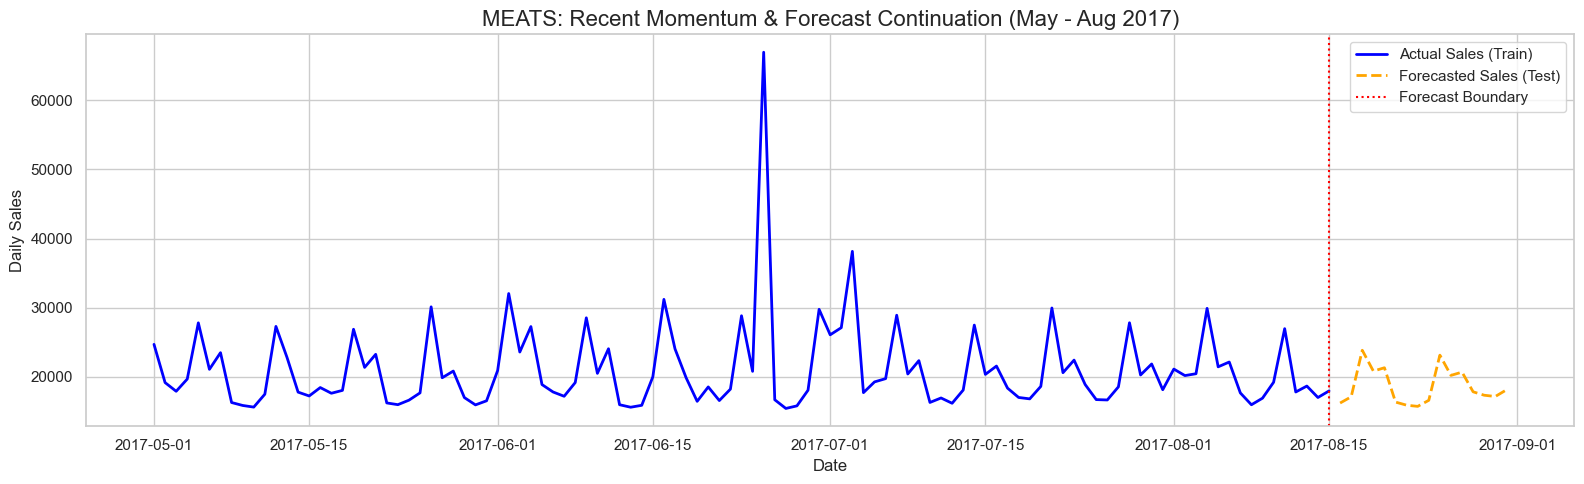

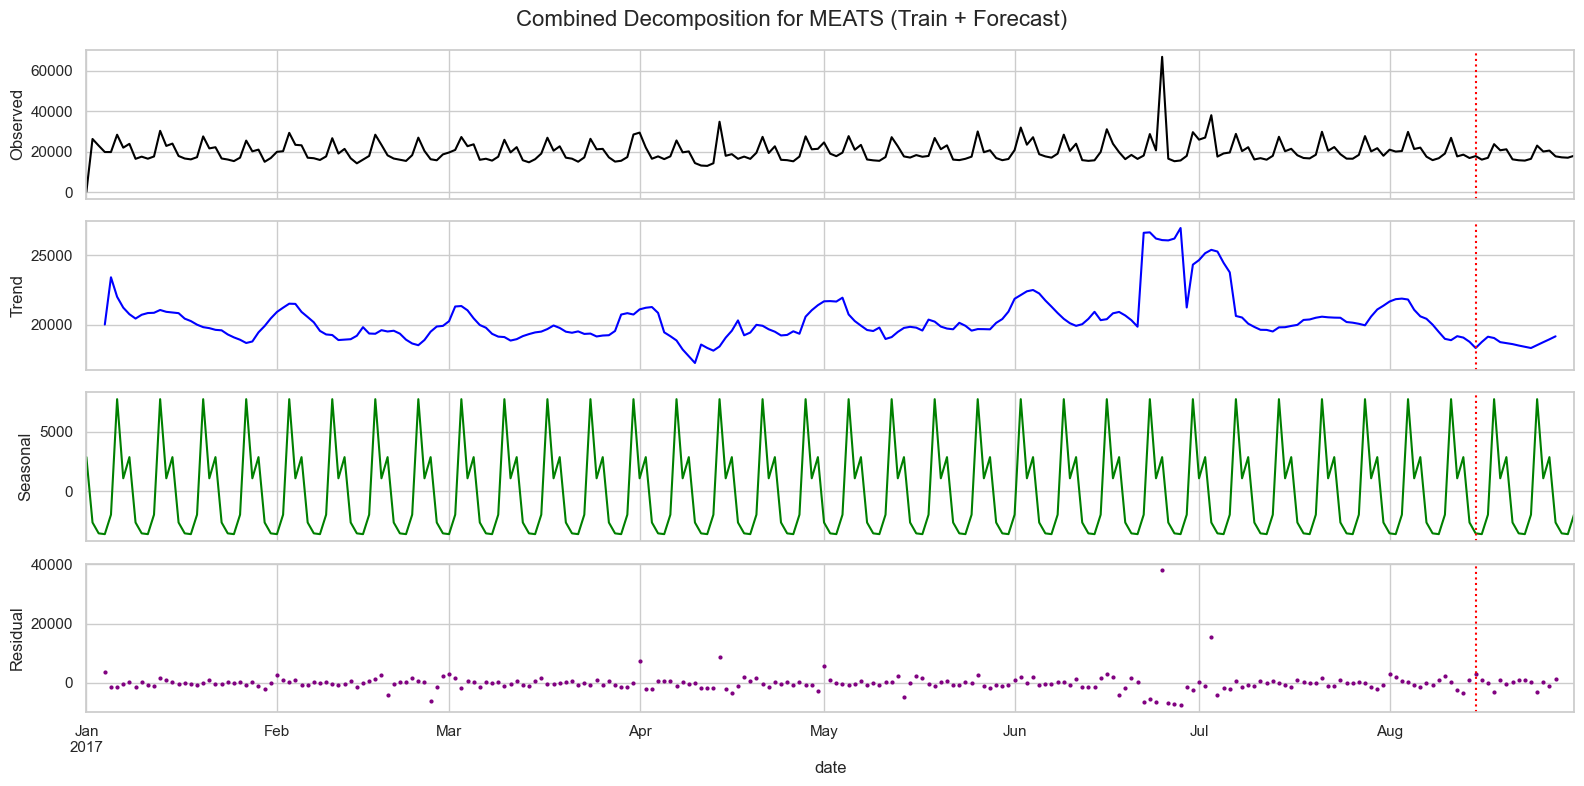

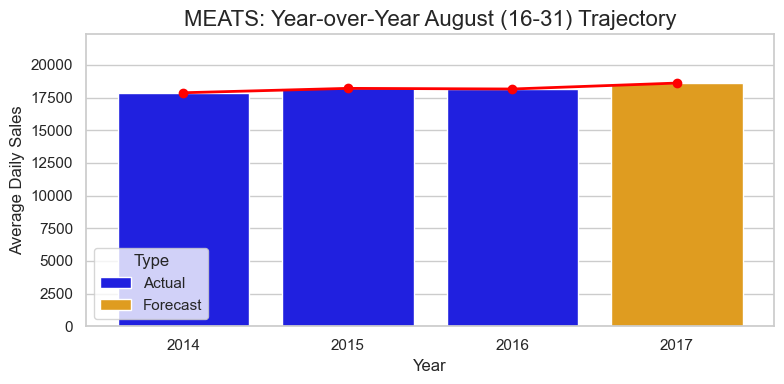

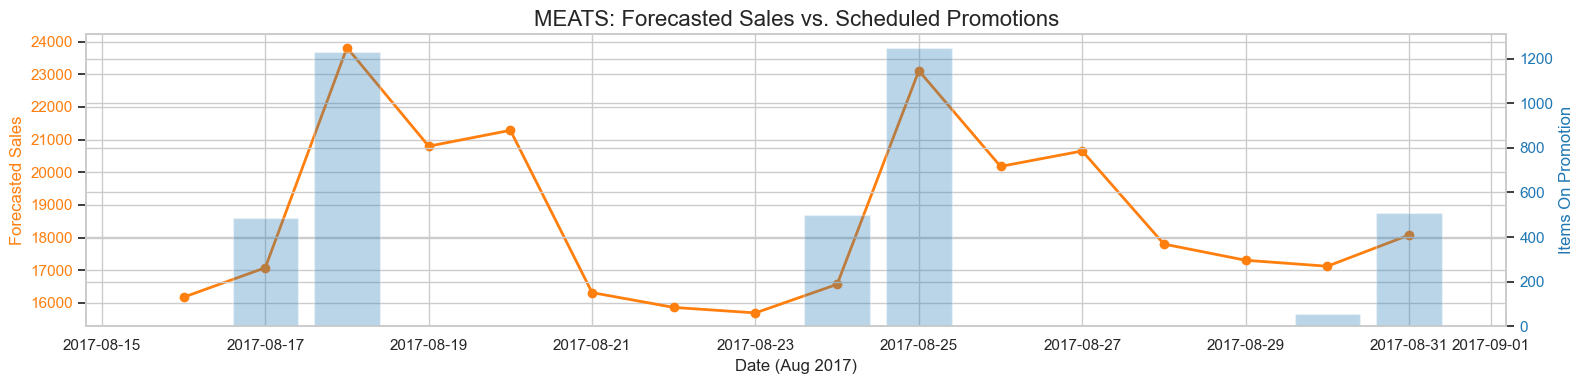


======================= EVALUATING FAMILY: PERSONAL CARE =======================


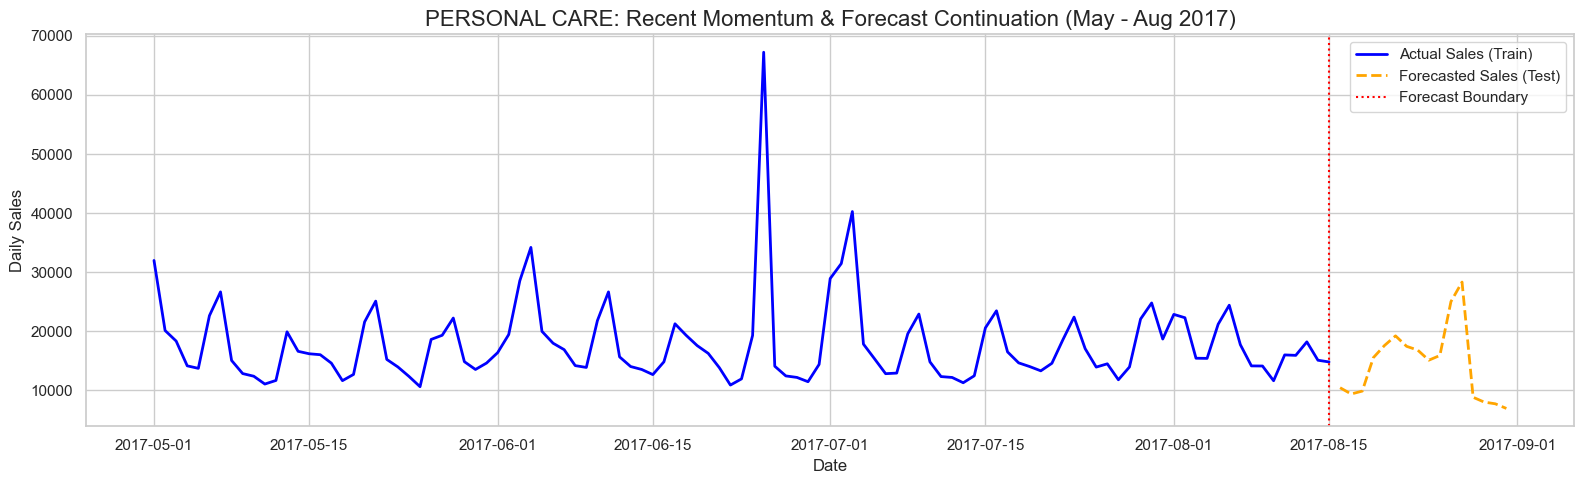

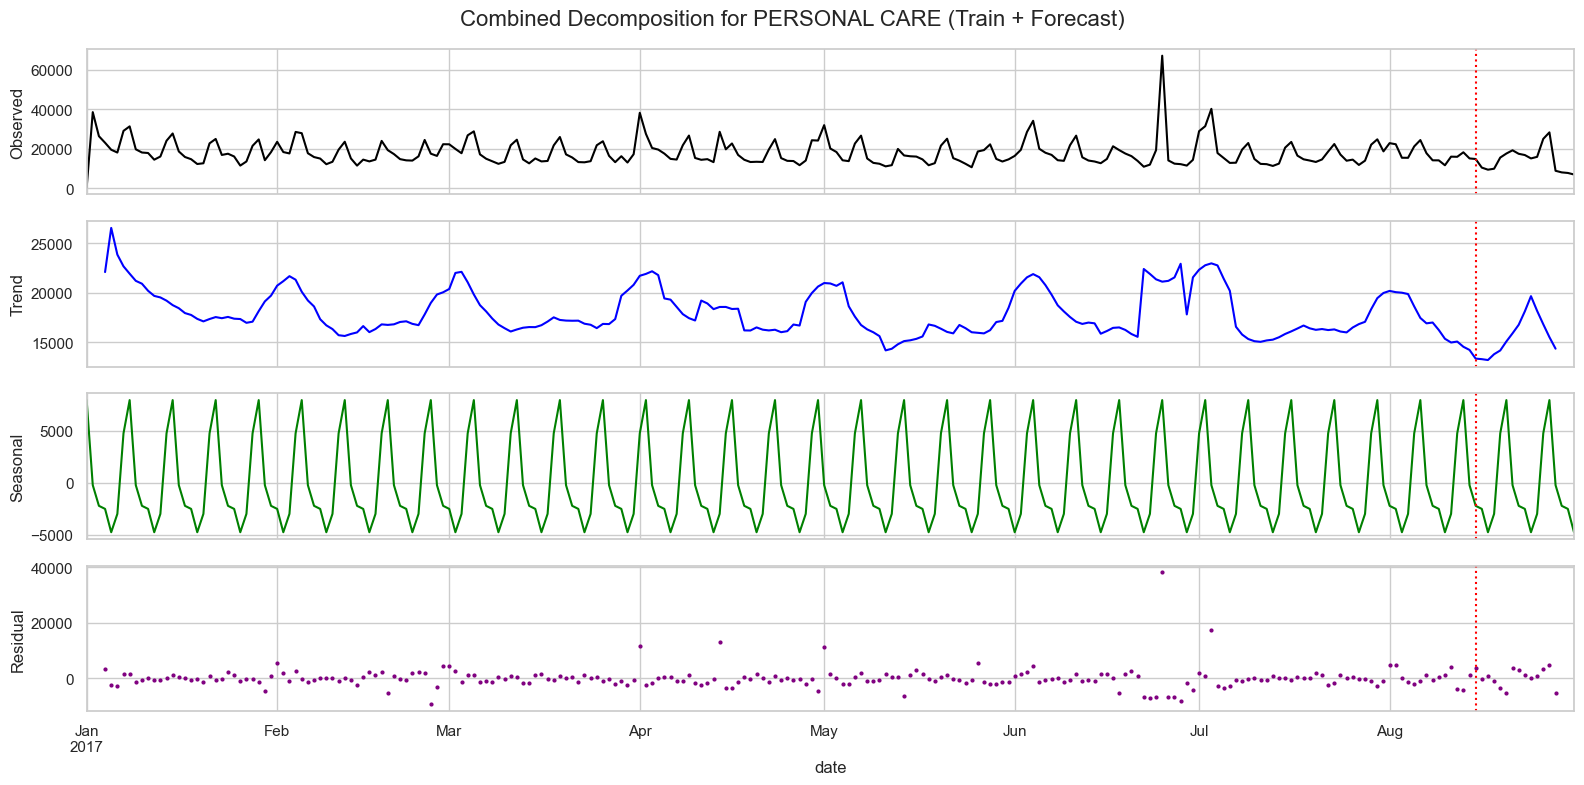

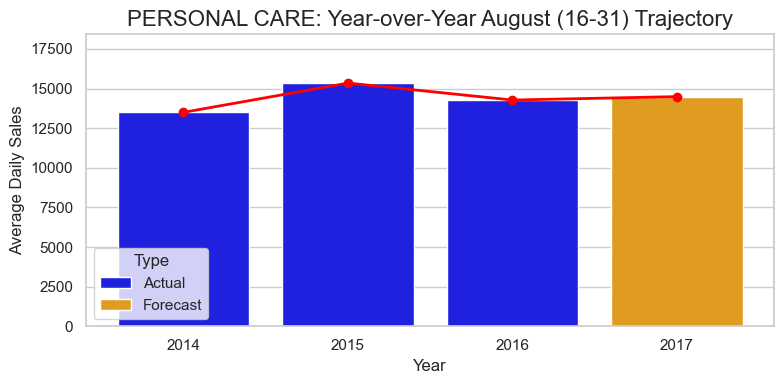

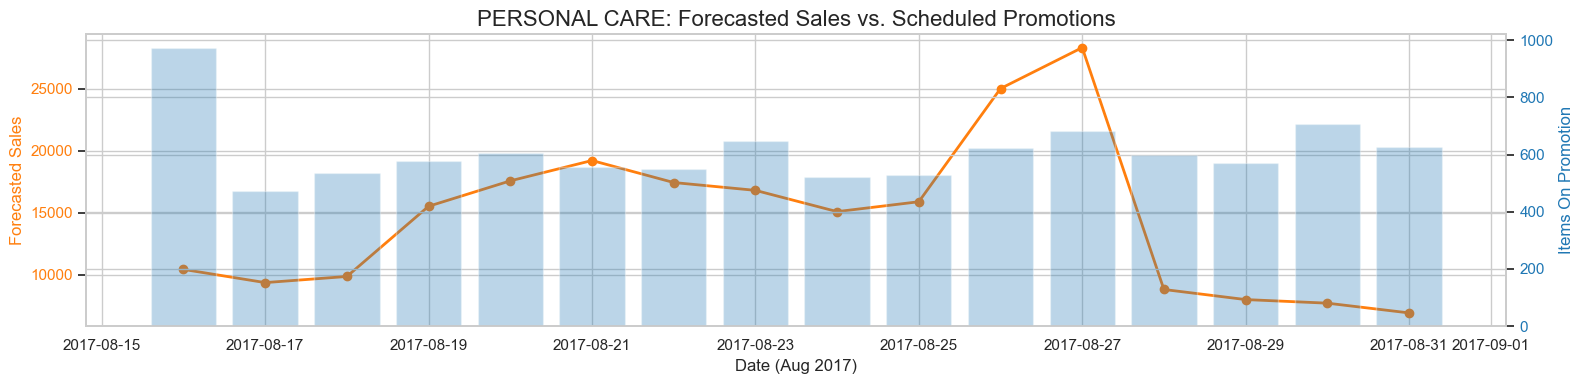


========================== EVALUATING FAMILY: POULTRY ==========================


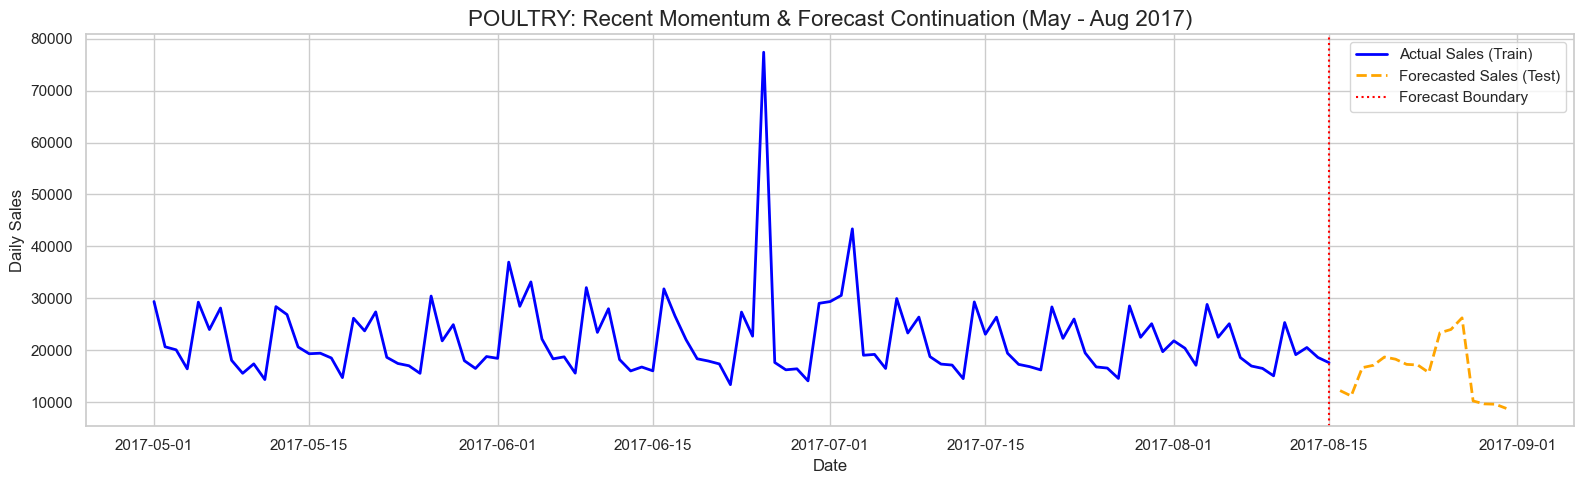

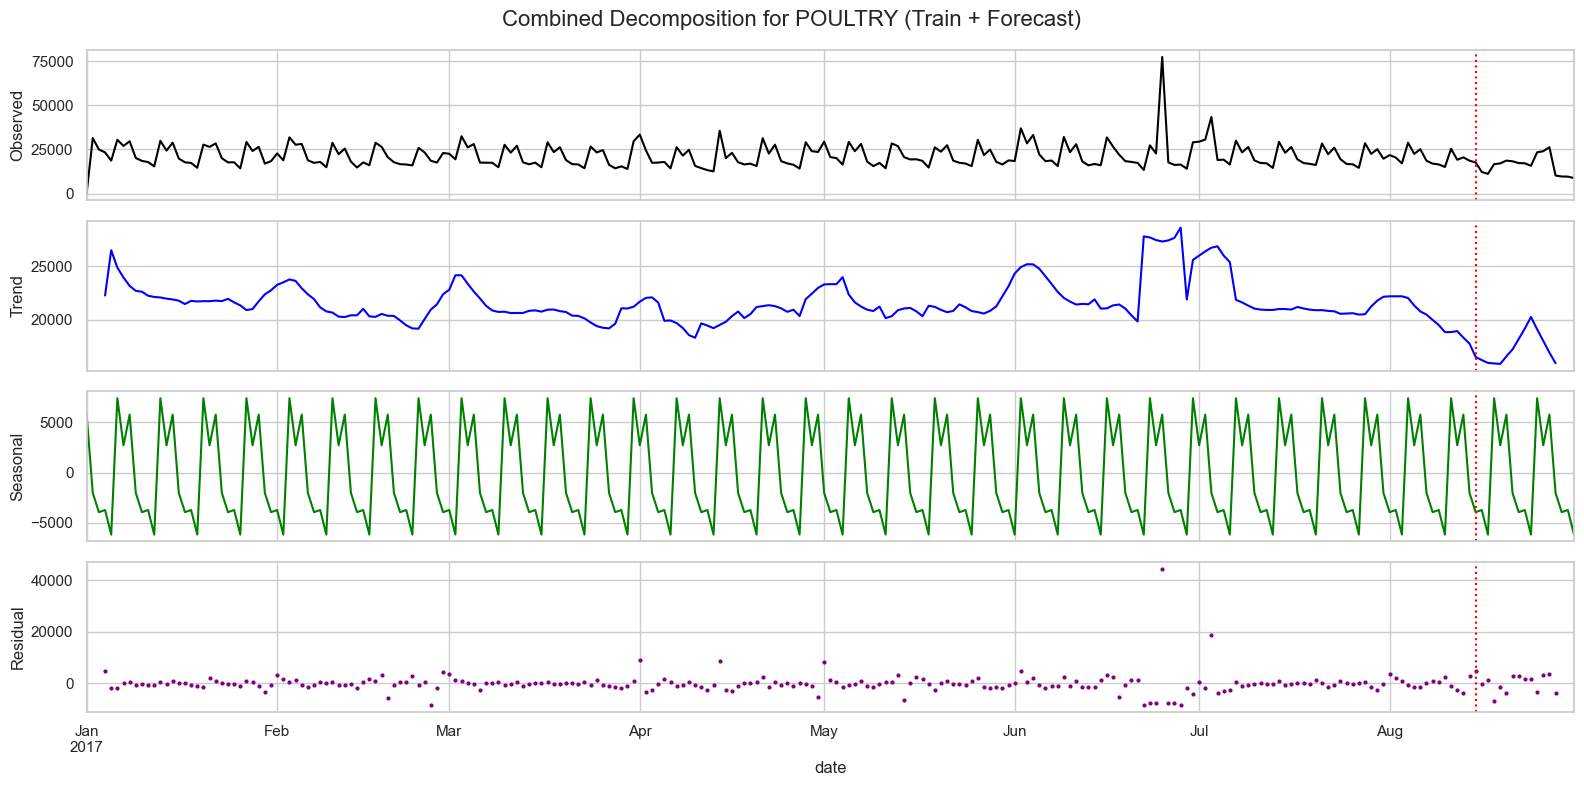

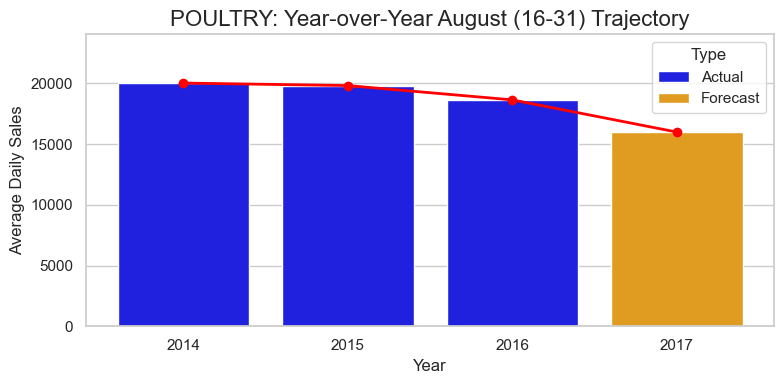

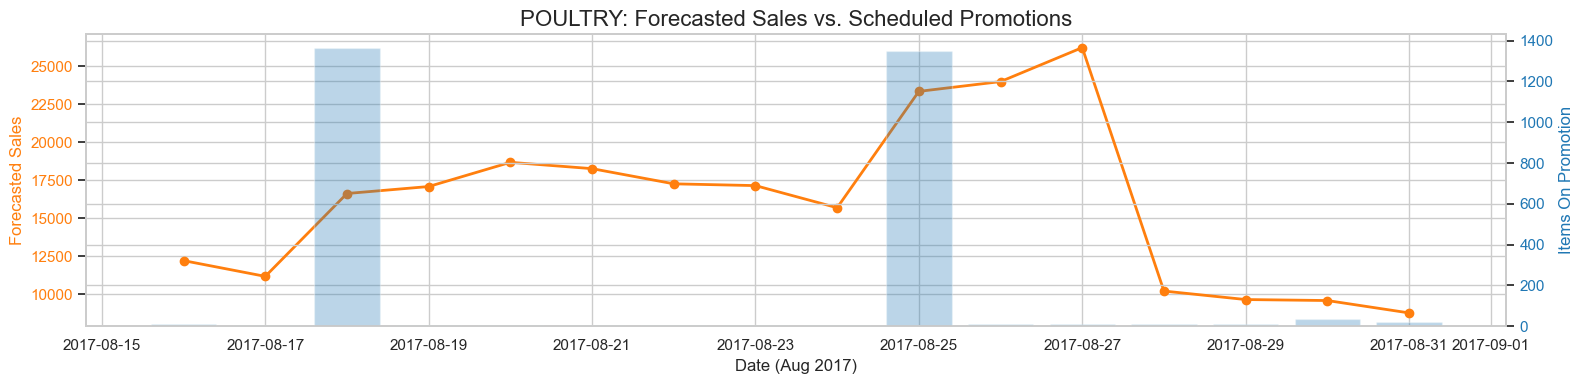


========================== EVALUATING FAMILY: PRODUCE ==========================


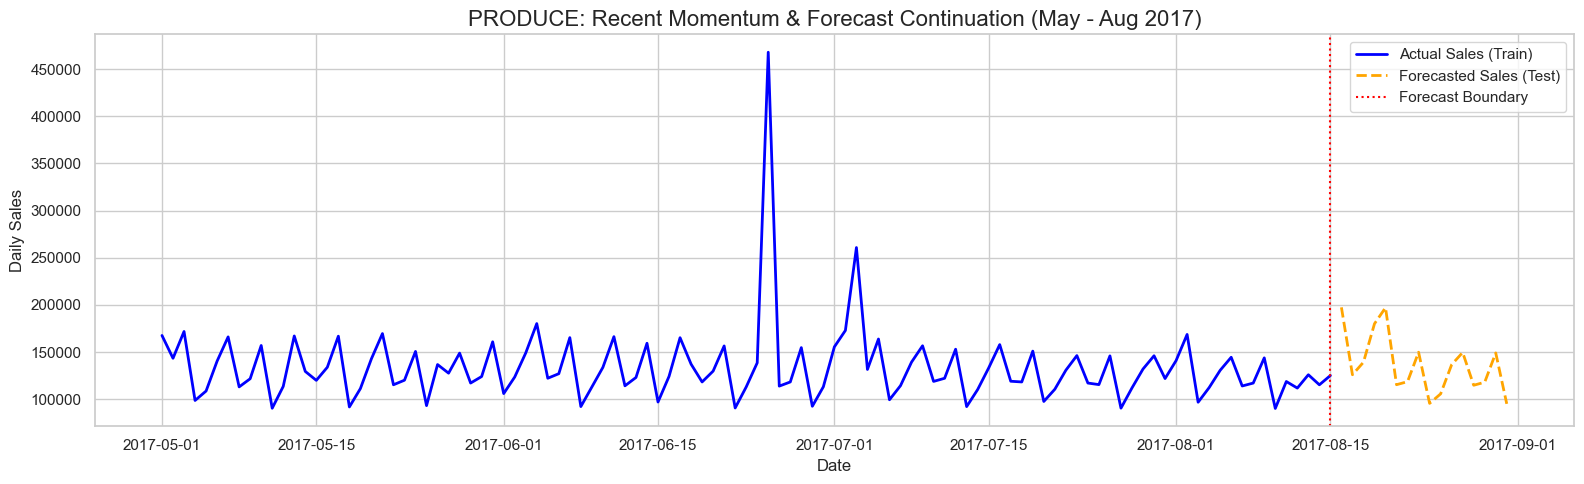

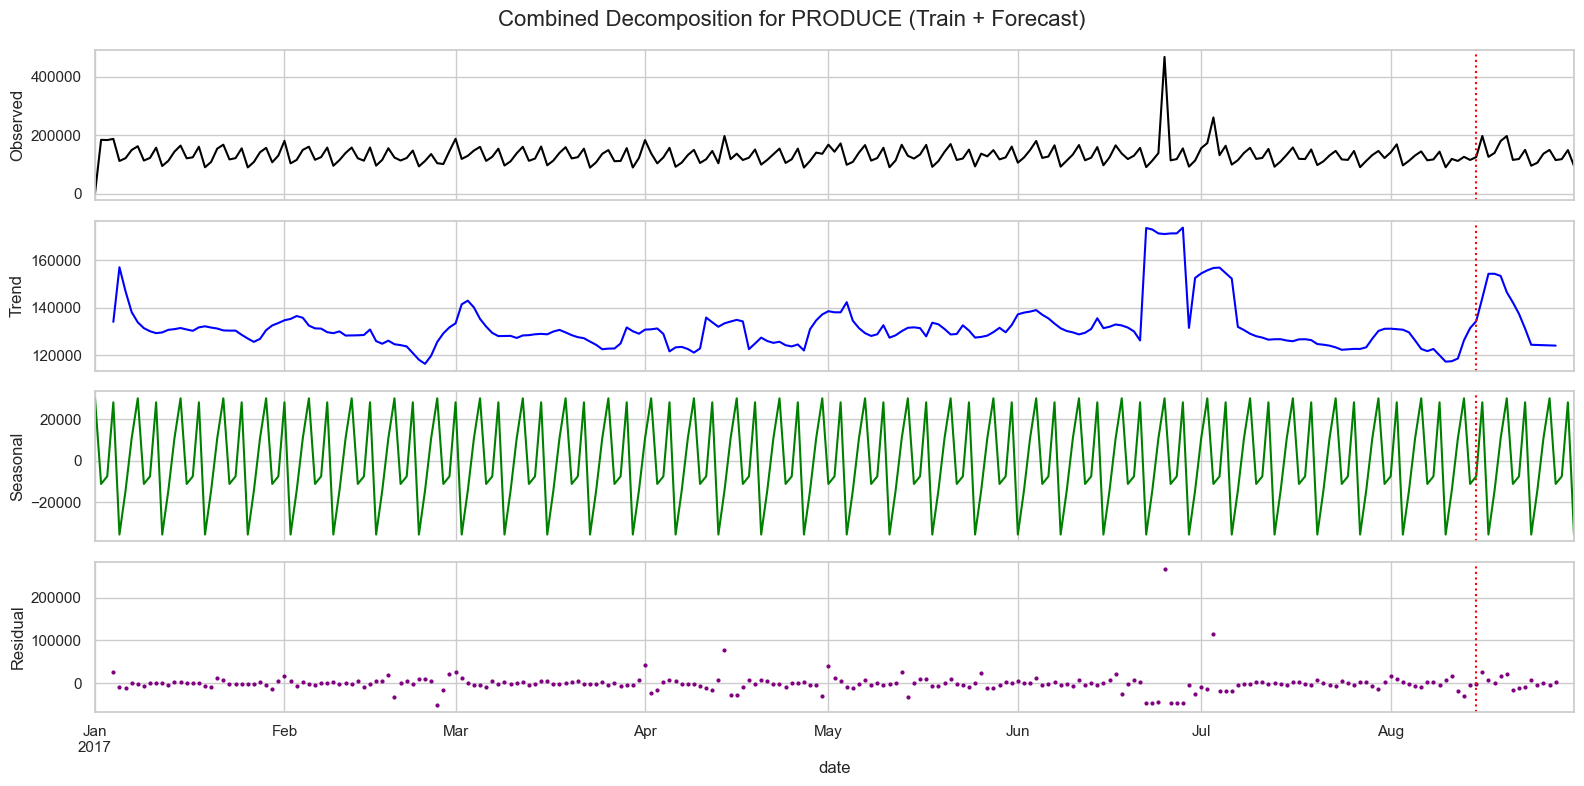

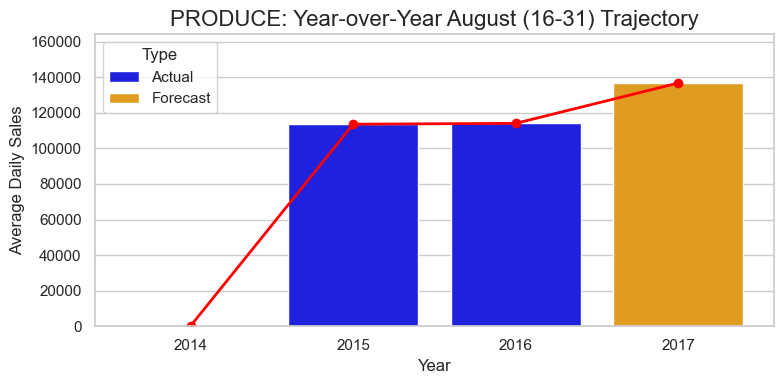

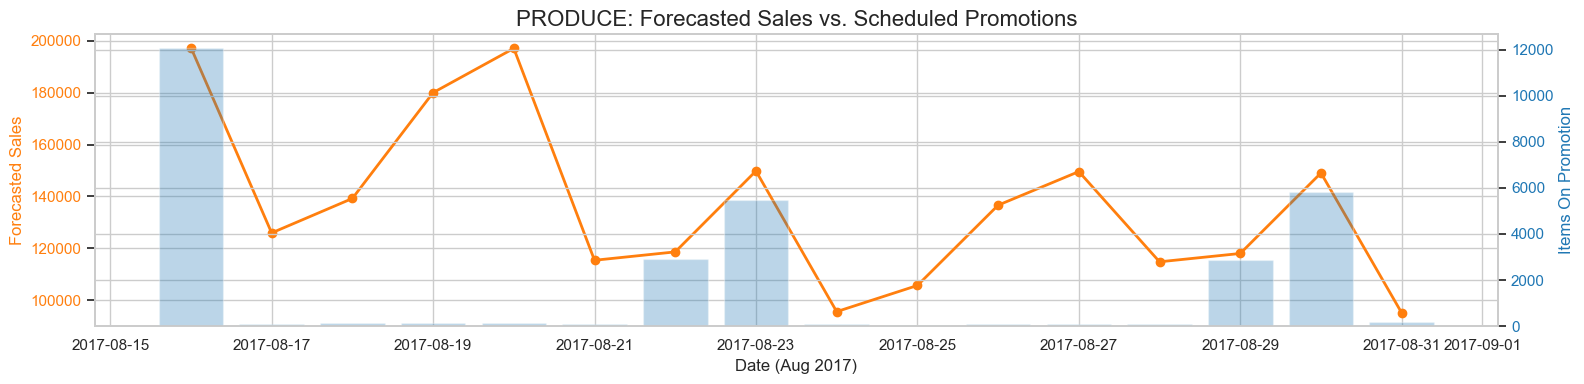

In [ ]:
# ==========================================
# EVALUATION LOOP
# ==========================================
# Define the 3 families we want to scrutinize
families_to_evaluate = forecasted_df.family.unique()

for family in families_to_evaluate:
    print("" + "="*80)
    print(f" EVALUATING FAMILY: {family} ".center(80, "="))
    print("="*80)
    
    # Generate Timeline
    combined_df, train_family, test_family = create_combined_timeline(train_df, test_pred_df, family)
    
    # Run Validations
    plot_visual_continuation(combined_df, family)

    # Seasonal decomposition is used here as a visual diagnostic, not as a strict validity test.
    # For nonlinear ML models such as XGBoost, the forecast is not expected to follow
    # a clean additive trend + seasonality + residual structure.
    # The goal is to detect extreme discontinuities or implausible seasonal behavior
    # before the forecast is used in inventory optimization.
    plot_combined_decomposition(combined_df, family)

    # YoY growth benchmarking is used as an operational plausibility check.
    # It does not prove that a model is statistically correct or incorrect.
    # Instead, it helps identify whether the forecast implies an unreasonable growth pattern
    # relative to the same calendar period in the previous year.
    plot_yoy_growth(train_family, test_family, family)

    # Exogenous cause-effect review is used to check whether forecast peaks or drops
    # are directionally consistent with known external drivers such as promotions,
    # holidays, oil-price movement, or special events.
    # This is a business-reasonableness audit, not a requirement that every model must
    # provide a linear coefficient-based explanation.
    plot_exogenous_effect(test_family, family, DATA)
    print("")
